In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt


In [2]:
def calculate_resistance_estimates(Vmeas, Imeas, time):

    den = - (Imeas[0:-2] - Imeas[1:-1])
    dt = time[0:-2] - time[1:-1]
    num = Vmeas[1:-1] - Vmeas[0:-2]
    idx = np.where((den < -1.5) & (np.abs(dt) < 10))[0]
    Rs_estimate = num[idx]/den[idx]

    return Rs_estimate, idx

In [3]:
PATHNAME = '/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch'

with open(f"{PATHNAME}/Cells_info.pkl", 'rb') as file:
    cells_info = pickle.load(file)

    # Fix: Only replace if it's NOT already "RT" or "55C"
    mask = ~cells_info['formation_temperature_c'].isin(['RT', '45C'])
    cells_info.loc[mask, 'formation_temperature_c'] = 'RT'
    cells_info.loc[cells_info['device_id'] == '152004', 'formation_type'] = 'FORMFAST_1'
    cells_info.loc[cells_info['device_id'] == '152016', 'formation_type'] = 'FORMBASE_1'
    cells_info = cells_info[cells_info['device_id'].astype(str) != '152022']
    cells_info.loc[cells_info['device_id'].between('152017', '152021'), 'formation_temperature_c'] = '45C'

cells_info

,device_id,formation_temperature_c,formation_pressure_psi,graphite_type,formation_type,cyc_temperature_c,cyc_pressure_psi
0,151802,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C
1,151803,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C
2,151804,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C
3,151805,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C
4,151806,RT,5P0PSI,1518,FORMBASE_1,45C,1C/1C
5,152001,RT,5P0PSI,1520,FORMBASE_1,45C,1C/1C
6,152002,RT,5P0PSI,1520,FORMBASE_1,45C,1C/1C
7,152004,RT,5P0PSI,1520,FORMFAST_1,45C,1C/1C
8,152005,RT,5P0PSI,1520,FORMFAST_2,45C,1C/1C
9,152006,RT,5P0PSI,1520,FORMFAST_2,45C,1C/1C


In [4]:
filtered_device_ids = cells_info[
    (cells_info['formation_pressure_psi'] == '5P0PSI') & 
    (cells_info['graphite_type'] == '1520') &
    (cells_info['formation_temperature_c'] == 'RT')
]

filtered_device_ids

formation_types = filtered_device_ids['formation_type'].unique()
idstr_dict = {temp: filtered_device_ids[filtered_device_ids['formation_type'] == temp]['device_id'].values for temp in formation_types}

idstr_dict



{'FORMBASE_1': array(['152001', '152002', '152007', '152008', '152013', '152014',
        '152016', '152026', '152064'], dtype=object),
 'FORMFAST_1': array(['152004', '152009', '152010', '152015', '152071'], dtype=object),
 'FORMFAST_2': array(['152005', '152006', '152011', '152012', '152023', '152098'],
       dtype=object)}

# Load data from a single file

In [13]:
df = pd.read_pickle(f"{PATHNAME}/UMBL2022FEB_CELL152071.pkl")


In [16]:
df['AuxDat']

,h_test_time,aux_vdf_ldcn_none_0,aux_vdf_refn_none_0,aux_vdf_current_amp_0,aux_vdf_ldcref_none_0,aux_vdf_refstd_none_0,aux_vdf_potential_volt_0,aux_vdf_testtime_second_0,aux_vdf_timestamp_datetime_0,aux_vdf_ambientrh_percent_0,aux_vdf_ldcsensor_none_0,aux_vdf_ldcscaled_none_0,aux_vdf_temperature_celsius_0,aux_vdf_datapointnumber_none_0,aux_vdf_ambienttemperature_celsius_0,h_datapoint_datetime
0,4.999222e+00,0.0,0.0,0.0,4294967295,0.0,0.0,4.999222e+00,1662082330870,17.2,4294967295,0.000000e+00,46.58,44890,45.1,2022-09-01 21:32:10.870000-04:00
1,1.000011e+01,0.0,0.0,0.0,4294967295,0.0,0.0,1.000011e+01,1662082335870,17.1,4294967295,0.000000e+00,46.60,44891,45.1,2022-09-01 21:32:15.870000-04:00
2,1.500016e+01,0.0,0.0,0.0,4294967295,0.0,0.0,1.500016e+01,1662082340870,17.2,4294967295,0.000000e+00,46.60,44892,45.1,2022-09-01 21:32:20.870000-04:00
3,1.999970e+01,0.0,0.0,0.0,4294967295,0.0,0.0,1.999970e+01,1662082345870,17.2,4294967295,0.000000e+00,46.59,44893,45.1,2022-09-01 21:32:25.870000-04:00
4,2.500018e+01,0.0,0.0,0.0,4294967295,0.0,0.0,2.500018e+01,1662082350870,17.2,4294967295,0.000000e+00,46.57,44894,45.1,2022-09-01 21:32:30.870000-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622086,3.110500e+06,0.0,100.0,0.0,7842800,13.0,0.0,3.110500e+06,1684949156980,10.4,4294967295,3.676479e+07,46.66,622093,45.4,2023-05-24 13:25:56.980000-04:00
622087,3.110505e+06,0.0,100.0,0.0,7842804,32.0,0.0,3.110505e+06,1684949161980,10.4,4294967295,3.676479e+07,46.67,622094,45.4,2023-05-24 13:26:01.980000-04:00
622088,3.110510e+06,0.0,100.0,0.0,7842804,32.0,0.0,3.110510e+06,1684949166980,10.4,4294967295,3.676479e+07,46.66,622095,45.4,2023-05-24 13:26:06.980000-04:00
622089,3.110515e+06,0.0,100.0,0.0,7842806,29.0,0.0,3.110515e+06,1684949171980,10.5,4294967295,3.676479e+07,46.66,622096,45.4,2023-05-24 13:26:11.980000-04:00


# Get all of the raw data in memory

In [23]:
# Convert 'h_datapoint_time' to seconds (assuming it's in datetime format)
h_datapoint_time_sec = pd.to_datetime(df['AuxDat']['h_datapoint_datetime']) \
    .astype(np.int64) // 10**9

# Convert 'aux_vdf_ambienttemperature_celsius_0' to a numeric vector
aux_ambient_temp = pd.to_numeric(df['AuxDat']['aux_vdf_ambienttemperature_celsius_0'])

In [24]:
h_datapoint_time_sec

0         1662082330
1         1662082335
2         1662082340
3         1662082345
4         1662082350
             ...    
622086    1684949156
622087    1684949161
622088    1684949166
622089    1684949171
622090    1684949176
Name: h_datapoint_datetime, Length: 3095508, dtype: int64

In [25]:
df['UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1']
x = pd.to_datetime(df['UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1']['h_datapoint_time']).astype(np.int64) // 10**9
y = pd.to_numeric(df['UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1']['h_potential'], errors='coerce')

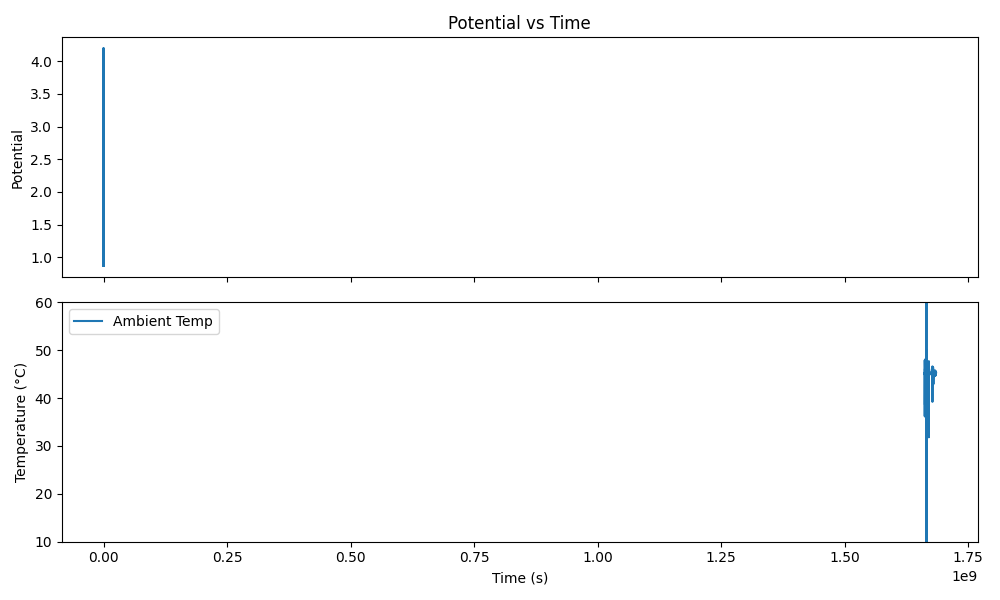

In [27]:
%matplotlib widget 

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(x, y)
axes[0].set_ylabel('Potential')
axes[0].set_title('Potential vs Time')

axes[1].plot(h_datapoint_time_sec, aux_ambient_temp, label='Ambient Temp')
# axes[1].plot(h_datapoint_time_sec, vdf_temp_0, label='VDF Temp 0')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylim(10, 60)
axes[1].legend()

plt.tight_layout()

In [61]:
PATHNAME = '/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch'

df_array = []
idstr_array = []
testname_array = []

count = 0
for idstr in list(idstr_dict['FORMFAST_2']):

    file_path = f"{PATHNAME}/UMBL2022FEB_CELL{idstr}.pkl"

    count += 1
    print(f'Processing "{file_path}", count = {count}...')

    if '152064' in idstr:
        print(f"✗ Skipping known problematic file: {file_path}")
        continue

    try:
        with open(file_path, 'rb') as file:
            data = pd.read_pickle(file)

        # Search for keys containing 'FORMBASE' or 'FORMFAST'
        matching_keys = [key for key in data.keys() if 'FORMBASE' in key or 'FORMFAST' in key]

        if len(matching_keys) == 1:
            test_name = matching_keys[0]
        elif len(matching_keys) == 2:
            test_name = matching_keys[0] if len(data[matching_keys[0]]) > len(data[matching_keys[1]]) else matching_keys[1]
        else:
            print(f"Warning: Expected one or two matching keys, but found {len(matching_keys)} for {file_path}")
            continue  # Skip this file instead of crashing

        df_array.append(data[test_name])
        idstr_array.append(idstr)
        testname_array.append(test_name)
        print(f"✓ Successfully processed {file_path}")
        
    except FileNotFoundError:
        print(f"✗ File not found: {file_path}")
        continue
    except Exception as e:
        print(f"✗ Error processing {file_path}: {e}")
        continue

print(f"\\nProcessing complete! Successfully loaded {len(df_array)} datasets out of {count} attempts.")

Processing "/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152005.pkl", count = 1...
✓ Successfully processed /Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152005.pkl
Processing "/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152006.pkl", count = 2...
✓ Successfully processed /Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152005.pkl
Processing "/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152006.pkl", count = 2...
✓ Successfully processed /Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152006.pkl
Processing "/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152011.pkl", count = 3...
✓ Successfully processed /Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152006.pkl
Processing "/Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152011.pkl", count = 3...
✓ Successfully processed /Users/ampere/Documents/PROJ_UMBL2022FEB/pouch/UMBL2022FEB_CELL152011.pkl


In [62]:
# Baseline
STEP_INDEX_HPPC_START = 11
STEP_INDEX_HPPC_END = STEP_INDEX_HPPC_START + 6
STEP_INDEX_CAP = 21

# Fast and Fast+
STEP_INDEX_HPPC_START = 13
STEP_INDEX_HPPC_END = STEP_INDEX_HPPC_START + 6
STEP_INDEX_CAP = 23

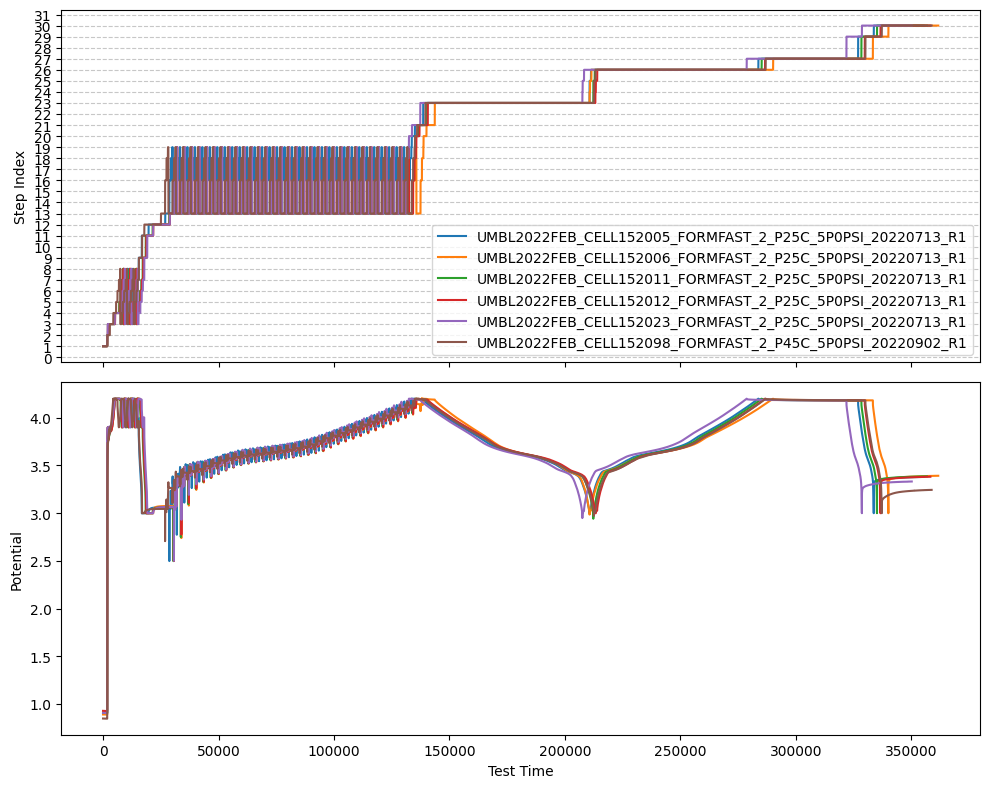

In [63]:

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for selected_data, idstr, testname in zip(df_array, idstr_array, testname_array):

    # First subplot: h_test_time vs h_step_index
    axes[0].plot(selected_data['h_test_time'], selected_data['h_step_index'], label=testname)
    axes[0].set_ylabel('Step Index')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].yaxis.set_major_locator(plt.MultipleLocator(1))

    # Second subplot: h_test_time vs h_potential
    axes[1].plot(selected_data['h_test_time'], selected_data['h_potential'], label=idstr)
    axes[1].set_xlabel('Test Time')
    axes[1].set_ylabel('Potential')

# Adjust layout
axes[0].legend()
plt.tight_layout()



In [64]:
rs_estimate_array = []
max_discharge_capacity_array = []

for selected_data, idstr, testname in zip(df_array, idstr_array, testname_array):


    # Filter the dataframe for the specified step index range
    hppc_data = selected_data[
        (selected_data['h_step_index'] >= STEP_INDEX_HPPC_START) & 
        (selected_data['h_step_index'] <= STEP_INDEX_HPPC_END)
    ]

    # Extract the relevant columns
    current = hppc_data['h_current']
    voltage = hppc_data['h_potential']
    time = hppc_data['h_test_time']

    current, voltage, time

    rs_estimate, idx = calculate_resistance_estimates(voltage.values, current.values, time.values)
    rs_estimate_array.append(rs_estimate)
    
    cap_data = selected_data[selected_data['h_step_index'] == STEP_INDEX_CAP]
    max_discharge_capacity = cap_data['h_discharge_capacity'].max()
    max_discharge_capacity_array.append(max_discharge_capacity)

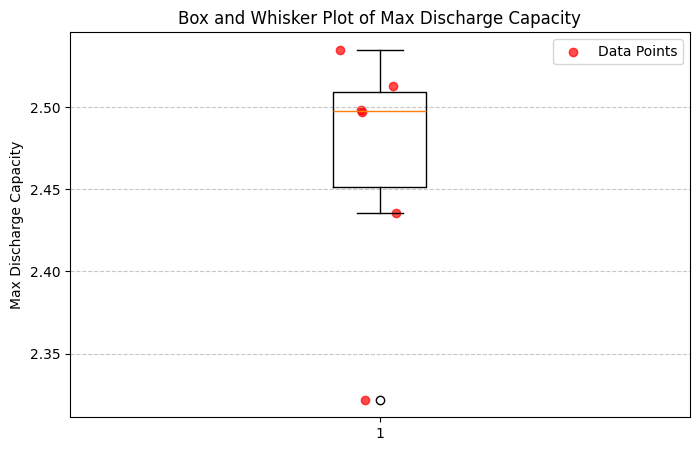

STD (Max Discharge Capacity): 0.0714
STD (Rs Estimate): 0.0043


In [65]:
plt.figure(figsize=(8, 5))
plt.boxplot(max_discharge_capacity_array, vert=True)

# Overlay individual data points with jitter for clarity
x_jitter = np.random.uniform(-0.08, 0.08, size=len(max_discharge_capacity_array))
plt.scatter(np.ones(len(max_discharge_capacity_array)) + x_jitter, max_discharge_capacity_array, color='red', alpha=0.7, label='Data Points')

plt.legend()
plt.ylabel('Max Discharge Capacity')
plt.title('Box and Whisker Plot of Max Discharge Capacity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

max_discharge_capacity_std = np.std(max_discharge_capacity_array) 
rs_flat = np.concatenate(rs_estimate_array)
rs_estimate_std = np.std(rs_flat) 

print(f"STD (Max Discharge Capacity): {max_discharge_capacity_std:.4f}")
print(f"STD (Rs Estimate): {rs_estimate_std:.4f}")